# Model A Development (Random Forest)

## 1. Import Libraries

In [1]:
import pandas as pd
import os

## 2. Load Preprocessed Data (from Anas)

In [3]:

# ".." means go up one level (out of notebooks folder)
# Then go into "data" folder
file_path = '../data/processed/dataset_final.csv'

try:
    df = pd.read_csv(file_path)
    print("✅ Data loaded successfully!")
    print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
    display(df.head())
except FileNotFoundError:
    print(f"❌ Error: Could not find file at {file_path}")
    # This helps you debug where Python is currently looking
    print("Current working directory:", os.getcwd())

✅ Data loaded successfully!
Rows: 1200, Columns: 41


,transaction_type_online purchase,transaction_type_transfer,transaction_type_withdrawal,merchant_category_Clothing,merchant_category_Crypto,merchant_category_Electronics,merchant_category_Entertainment,merchant_category_Food,merchant_category_Gambling,merchant_category_Services,...,account_age_days,description_risk_score,transaction_frequency_24h,num_failed_transactions_7d,transaction_hour,is_weekend,num_devices_used,num_countries_used,kyc_verified,is_fraud
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.929790,-0.368841,0.0,0.0,8.0,0.0,2.0,0.0,0.0,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.761706,-0.368841,0.0,0.0,7.0,0.0,2.0,0.0,1.0,0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.964482,-0.368841,0.0,0.0,19.0,0.0,1.0,0.0,0.0,1
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.560900,3.310755,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.064750,-0.368841,0.0,0.0,10.0,0.0,2.0,0.0,0.0,0


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Load Data (Using relative path for teamwork)
file_path = '../data/processed/dataset_final.csv' 
# fallback if file is in main folder: file_path = '../synthetic_fraud_dataset_final.csv'

df = pd.read_csv(file_path)

# 2. Feature Selection
# Drop ID columns and raw text that we aren't using for Model A (Orai handles text features)
# We also drop 'risk_category' to avoid data leakage if it was derived from the target
cols_to_drop = [
    'transaction_id', 'timestamp', 'customer_id', 
    'transaction_description', 'merchant_name', 'customer_support_note',
    'risk_category' 
]
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 3. Encoding Categorical Variables
# Convert strings (like 'payment_channel') to numbers
# We use One-Hot Encoding for categorical data
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# 4. Split X (Features) and y (Target)
X = df_encoded.drop('is_fraud', axis=1)
y = df_encoded['is_fraud']

# 5. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Shape: {X_train.shape}")
print(f"Testing Shape: {X_test.shape}")

Training Shape: (960, 40)
Testing Shape: (240, 40)


## 3. Baseline Model Training

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Initialize Baseline Model (Default parameters)
rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train, y_train)

# Predictions
y_pred_base = rf_baseline.predict(X_test)
y_prob_base = rf_baseline.predict_proba(X_test)[:, 1]

# Evaluation
print("--- Baseline Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_base):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_base))

--- Baseline Model Performance ---
Accuracy: 0.8458
ROC-AUC: 0.7120

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.98      0.91       188
           1       0.86      0.35      0.49        52

    accuracy                           0.85       240
   macro avg       0.85      0.67      0.70       240
weighted avg       0.85      0.85      0.82       240



## 4. Hyperparameter Tuning

In [7]:
from sklearn.model_selection import GridSearchCV

# Define the "Grid" of settings to test
param_grid = {
    'n_estimators': [50, 100, 200],      # Number of trees
    'max_depth': [None, 10, 20],         # How deep the trees can go
    'min_samples_split': [2, 5, 10]      # Minimum samples to split a node
}

# Initialize Grid Search
# cv=3 means it tests 3 times for each combination (Cross-Validation)
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,  # Use all processor cores
    verbose=1
)

# Run the search (This might take a minute)
print("Starting Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)

# Get best model
best_rf = grid_search.best_estimator_

print("\n✅ Tuning Complete!")
print(f"Best Parameters: {grid_search.best_params_}")

Starting Hyperparameter Tuning...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

✅ Tuning Complete!
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


## 5. Evaluation & Comparison

In [8]:
# Predict with the Tuned Model
y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

# metrics
acc_tuned = accuracy_score(y_test, y_pred_tuned)
auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("--- Tuned Model Performance ---")
print(f"Accuracy: {acc_tuned:.4f}")
print(f"ROC-AUC: {auc_tuned:.4f}")

# Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC'],
    'Baseline Model': [accuracy_score(y_test, y_pred_base), roc_auc_score(y_test, y_prob_base)],
    'Tuned Model': [acc_tuned, auc_tuned]
})

display(comparison_df)

--- Tuned Model Performance ---
Accuracy: 0.8542
ROC-AUC: 0.7009


,Metric,Baseline Model,Tuned Model
0,Accuracy,0.845833,0.854167
1,ROC-AUC,0.712050,0.700900


In [11]:
from sklearn.model_selection import cross_val_score

# We use Cross-Validation (CV) to prove our model isn't just lucky.
# It splits the data into 5 parts, training on 4 and testing on 1, five times.

print("--- Starting 5-Fold Cross-Validation ---")

# We use the 'best_rf' model found in Week 9
# scoring='accuracy' gives us the % correct for each run
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='accuracy')

print(f"CV Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

# Interpretation logic
if cv_scores.std() < 0.05:
    print("✅ Result: The model is STABLE. It performs consistently across different data splits.")
else:
    print("⚠️ Result: The model is UNSTABLE. Performance varies too much.")

--- Starting 5-Fold Cross-Validation ---
CV Accuracy Scores: [0.890625   0.859375   0.84375    0.86979167 0.859375  ]
Mean Accuracy: 0.8646
Standard Deviation: 0.0155
✅ Result: The model is STABLE. It performs consistently across different data splits.


C:\Users\Nazrul Ikram\AppData\Local\Temp\ipykernel_19052\2412232281.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')


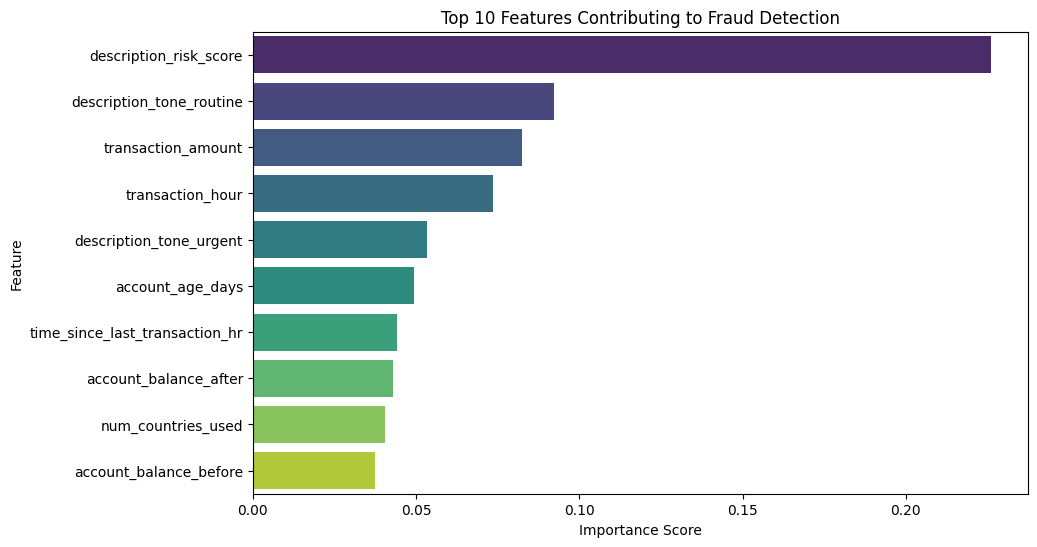

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance from the best model
importances = best_rf.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for plotting
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Features Contributing to Fraud Detection')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()